In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv('../data/processed/uber.csv')

In [20]:
pd.set_option('display.max_column', None)

## What is the average driver and customer rating by vehicle type?

In [92]:
avg_rating = df.groupby('vehicle_type').agg(
    cust_rating = ('customer_rating', 'mean'),
    driv_rating = ('driver_rating', 'mean')
).reset_index()
avg_rating

,vehicle_type,cust_rating,driv_rating
0,Auto,4.402000,4.232369
1,Bike,4.403940,4.230056
2,Go Mini,4.404297,4.227694
3,Go Sedan,4.409996,4.231812
4,Premier Sedan,4.403457,4.234865
5,Uber XL,4.404851,4.238340
6,eBike,4.403954,4.225614


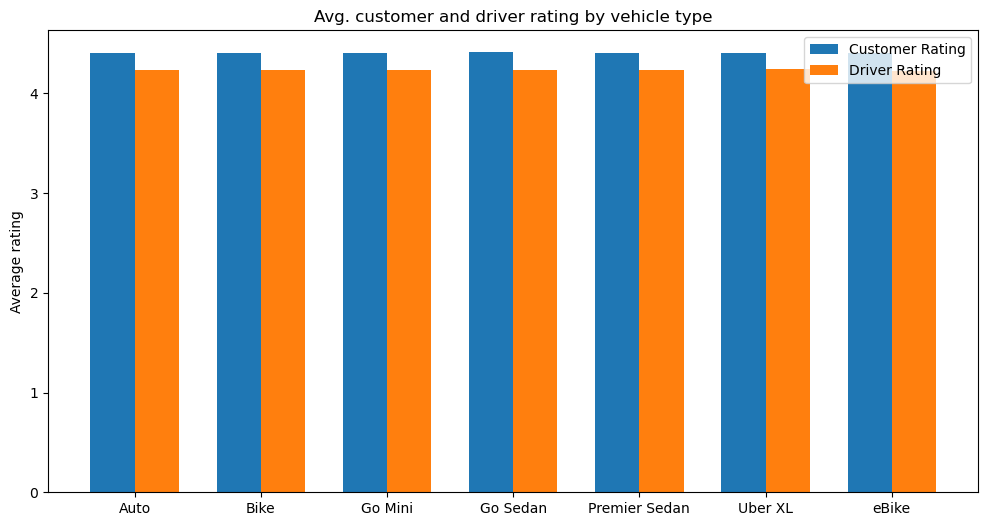

In [100]:
x = np.arange(len(avg_rating['vehicle_type']))  
width = 0.35 

# Create bars
plt.figure(figsize=(12,6))
plt.bar(x - width/2, avg_rating['cust_rating'], width, label='Customer Rating')
plt.bar(x + width/2, avg_rating['driv_rating'], width, label='Driver Rating')

plt.xticks(x, avg_rating['vehicle_type'])
plt.ylabel('Average rating')
plt.title('Avg. customer and driver rating by vehicle type')
plt.legend()

plt.show()

## Do cancelled or incomplete rides affect ratings?

In [115]:
df.groupby('status').agg(
    avg_driv_rating=('driver_rating', 'mean'),
    avg_cust_rating=('customer_rating', 'mean')
).reset_index()

,status,avg_driv_rating,avg_cust_rating
0,Cancelled by Customer,NaN,NaN
1,Cancelled by Driver,NaN,NaN
2,Completed,4.230992,4.404584
3,Incomplete,NaN,NaN
4,No Driver Found,NaN,NaN


## Is there a correlation between ride distance/fare and ratings?

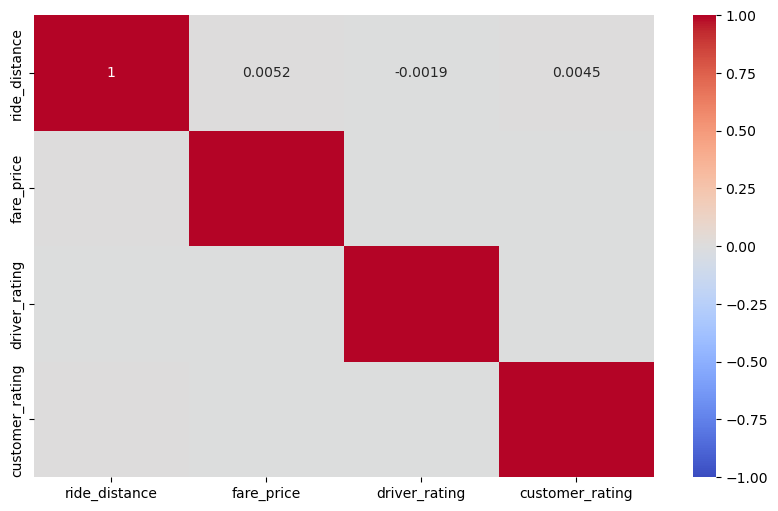

In [147]:
corr = df[['ride_distance','fare_price','driver_rating', 'customer_rating']].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)

plt.show()